C:\Users\fusb1\AppData\Local\Temp\ipykernel_11080\3419040040.py:86: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
C:\Users\fusb1\AppData\Local\Temp\ipykernel_11080\3419040040.py:87: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['

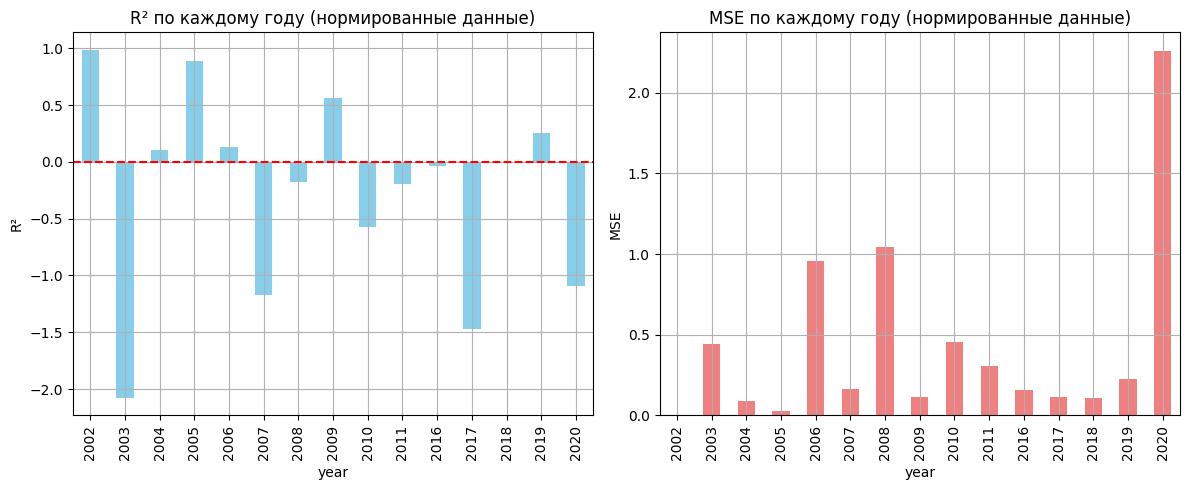

MSE: 0.3485
RMSE: 0.5903
R²: 0.1647


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

y1_path = "C:/Users/fusb1/Desktop/После Рыбки/Y_глубины/Y1_(глубина_=_0).csv"
r1_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_3_daily_Mean_Chla.csv"
r2_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_4.5_daily_Mean_Chla.csv"
r3_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_6_daily_Mean_Chla.csv"
s1_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_3000_матрица_из_ячеек_все_годы.csv"
s2_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_4500_матрица_из_ячеек_все_годы.csv"
s3_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_6000_матрица_из_ячеек_все_годы.csv"

df_y = pd.read_csv(y1_path)
df_y.columns = ['date', 'chlorophyll']
df_y['date'] = pd.to_datetime(df_y['date'])
df_y['chlorophyll'] = df_y['chlorophyll'].astype(str).str.replace(r'[^0-9,\.]', '', regex=True).str.replace(',', '.')
df_y['chlorophyll'] = pd.to_numeric(df_y['chlorophyll'], errors='coerce')

def load_r(path, name):
    df = pd.read_csv(path)
    df = df[['date', 'chla_mean']]
    df = df.rename(columns={'chla_mean': name})
    df['date'] = pd.to_datetime(df['date'])
    return df

r1 = load_r(r1_path, 'R1')
r2 = load_r(r2_path, 'R2')
r3 = load_r(r3_path, 'R3')

r_all = r1.merge(r2, on='date').merge(r3, on='date')
r_features = r_all[['R1', 'R2', 'R3']]
r_p95 = r_features.quantile(0.99)
r_clipped = r_features.clip(upper=r_p95, axis=1)
r_normalized = r_clipped / r_p95
r_normalized['date'] = r_all['date']

def load_s(path, name):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    df.columns = [f'{name}_{col}' for col in df.columns]
    return df

s1 = load_s(s1_path, 'S1')
s2 = load_s(s2_path, 'S2')
s3 = load_s(s3_path, 'S3')

df_x = r_normalized.copy()
df_x = df_x.set_index('date')
df_x = df_x.join([s1, s2, s3])
df_x = df_x.reset_index()

df = pd.merge(df_x, df_y, on='date', how='inner')
df = df.dropna(subset=['chlorophyll'])

features = df.drop(columns=['date', 'chlorophyll', 'R1', 'R2', 'R3'])  # только S
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

X_scaled = pd.concat([df[['R1', 'R2', 'R3']].reset_index(drop=True), features_scaled], axis=1)
X_scaled['date'] = df['date'].values
y = df['chlorophyll']
groups = df['date'].dt.year

model = HistGradientBoostingRegressor(random_state=42, max_iter=100)
logo = LeaveOneGroupOut()
y_pred = cross_val_predict(model, X_scaled.drop(columns='date'), y, cv=logo, groups=groups)

df_result = df[['date']].copy()
df_result['y_true'] = y
df_result['y_pred'] = y_pred
df_result['year'] = df_result['date'].dt.year

r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_pred']))

# Графики
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
r2_by_year.plot(kind='bar', color='skyblue')
plt.axhline(0, color='red', linestyle='--')
plt.title('R² по каждому году (нормированные данные)')
plt.ylabel('R²')
plt.grid(True)

plt.subplot(1, 2, 2)
mse_by_year.plot(kind='bar', color='lightcoral')
plt.title('MSE по каждому году (нормированные данные)')
plt.ylabel('MSE')
plt.grid(True)

plt.tight_layout()
plt.show()

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
